In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
Vehicle_number = 1994

In [4]:
# Produce the date range for the year 2023
date = '2023-01-01'
dti = pd.date_range(date, freq="d", periods=365)
date = dti.strftime('%Y-%m-%d')
print(date)

Index(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
       '2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09', '2023-01-10',
       ...
       '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26',
       '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30', '2023-12-31'],
      dtype='object', length=365)


In [5]:
# create a three-dimensional array to store the pixel values of the images
image_no = 365
image_size = 128
arr = np.zeros((image_no, image_size, image_size)) # 365 images of 28x28 pixels
print(arr.shape)

for d in range(image_no):
    try:
        Vehicle_image= Image.open('Vehicle_'+str(Vehicle_number)+'/'+str(date[d])+'.png').convert('L')
        reducesizeimgage = Vehicle_image.resize((image_size,image_size))
        #resultImage = reducesizeimgage.resize(Vehicle_image.size, Image.NEAREST)
        image_arr = np.array(reducesizeimgage)
        arr[d,:,:] = image_arr
    except:pass

(365, 128, 128)


In [6]:
non_empty_mask = ~np.all(arr == 0, axis=(1, 2))

arr = arr[non_empty_mask]
arr_date = np.array(date)[non_empty_mask]

print("Filtered arr shape:", arr.shape)
print("Filtered dates:", arr_date, len(arr_date))


Filtered arr shape: (295, 128, 128)
Filtered dates: ['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-12' '2023-01-13' '2023-01-14'
 '2023-01-18' '2023-01-23' '2023-01-24' '2023-01-25' '2023-01-26'
 '2023-01-27' '2023-01-29' '2023-01-30' '2023-01-31' '2023-02-01'
 '2023-02-02' '2023-02-03' '2023-02-04' '2023-02-05' '2023-02-06'
 '2023-02-07' '2023-02-08' '2023-02-09' '2023-02-10' '2023-02-12'
 '2023-02-13' '2023-02-14' '2023-02-15' '2023-02-16' '2023-02-17'
 '2023-02-18' '2023-02-19' '2023-02-20' '2023-02-21' '2023-02-22'
 '2023-02-25' '2023-02-26' '2023-03-02' '2023-03-03' '2023-03-04'
 '2023-03-05' '2023-03-06' '2023-03-07' '2023-03-09' '2023-03-10'
 '2023-03-11' '2023-03-13' '2023-03-14' '2023-03-15' '2023-03-16'
 '2023-03-17' '2023-03-18' '2023-03-19' '2023-03-20' '2023-03-21'
 '2023-03-22' '2023-03-23' '2023-03-25' '2023-03-26' '2023-03-27'
 '2023-03-28' '2023-03-29' '2023-03-30' '2023-03-31' '2023-04-01'
 '2023-04-02' '2023-04-0

In [7]:
# store the array in a CSV file
df = pd.DataFrame(arr.reshape(arr.shape[0], -1))
df['date'] = arr_date
df.to_csv('arr_date'+str(Vehicle_number)+'.csv', index=False)

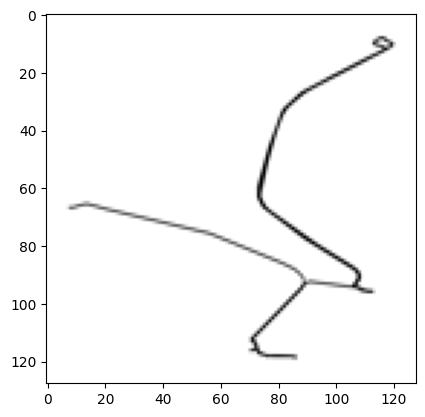

In [8]:
# Display the first image
plt.imshow(arr[0,:,:], cmap='gray')
plt.show()

In [9]:
import tensorflow as tf

index = np.arange(0, 365)
index = index[non_empty_mask]

#park_pass
park_pass_dataframe = pd.DataFrame()
hour_pass = pd.read_csv('hourly_passing_per_truck_1D_8SQ_CLUSTER_for_test_'+str(Vehicle_number)+'_R copy.csv')
for i in range(len(index)):
    park_pass = hour_pass[hour_pass[' TruckId'] == str(Vehicle_number)+'-'+str(i)]
    # sum the columns 2 to 26
    park_pass = park_pass.iloc[:, 2:27].sum(axis=1)
    park_pass_dataframe[i] = park_pass.values

# transfer all non-zero values to 1
park_pass_dataframe[park_pass_dataframe > 0] = 1
print(park_pass_dataframe.head())
park_pass_dataframe = park_pass_dataframe.T
print(park_pass_dataframe.shape)

park_pass_tensor = tf.convert_to_tensor(park_pass_dataframe.values, dtype=tf.float32)
print(park_pass_tensor.shape)



2025-05-06 07:48:32.278053: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


   0    1    2    3    4    5    6    7    8    9    ...  285  286  287  288  \
0    0    0    0    0    1    1    0    0    0    0  ...    0    0    1    0   
1    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    1    1    1    1    1    1    1    0    1    0  ...    1    0    1    0   
3    1    1    1    1    1    1    1    1    1    1  ...    1    1    1    1   
4    1    1    1    0    1    0    1    0    1    1  ...    0    1    1    0   

   289  290  291  292  293  294  
0    0    0    0    0    0    1  
1    0    0    0    1    0    0  
2    0    0    0    1    1    1  
3    1    1    1    1    1    1  
4    1    1    0    0    1    1  

[5 rows x 295 columns]
(295, 8)
(295, 8)


/var/folders/9p/t6ljp_1516q16t2lqgyjw0w80000gp/T/ipykernel_17567/2699875506.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  park_pass_dataframe[i] = park_pass.values
/var/folders/9p/t6ljp_1516q16t2lqgyjw0w80000gp/T/ipykernel_17567/2699875506.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  park_pass_dataframe[i] = park_pass.values
/var/folders/9p/t6ljp_1516q16t2lqgyjw0w80000gp/T/ipykernel_17567/2699875506.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

In [10]:
import tensorflow as tf

# append two arrays to create the training dataset
x_train = arr
x_train = x_train[..., tf.newaxis]  # (batch, 28, 28, 1)
print(x_train.shape)

x_train = x_train.astype('float32') / 255.


(295, 128, 128, 1)


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import layers, losses
from tensorflow.keras.callbacks import EarlyStopping

class Autoencoder(Model):
    def __init__(self, latent_dim, shape, num_classes=8):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.shape = shape
        self.num_classes = num_classes

        # Encoder: now expects (1 + num_classes) input channels
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(128, 128, 1 + num_classes)),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu'),
        ])
        
        # Decoder: same as before
        self.decoder = tf.keras.Sequential([
            layers.Input(shape = (latent_dim,)),
            layers.Dense(16*16*64, activation='relu'),  # Calculate size of flattened output
            layers.Reshape((16, 16, 64)),
            layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2),
            layers.BatchNormalization(),
            layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2),
            layers.BatchNormalization(),
            layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same', strides=2),
        ])

        self.encoder.summary()
        self.decoder.summary()

    def call(self, inputs):
        img, labels_onehot = inputs  # Expect a tuple (image, one-hot label)

        # Expand one-hot vector into full (H, W, num_classes) maps
        label_map = tf.reshape(labels_onehot, (-1, 1, 1, self.num_classes))  # (batch, 1, 1, 10)
        label_map = tf.tile(label_map, [1, img.shape[1], img.shape[2], 1])    # (batch, 128, 128, 10)

        # Concatenate along channels
        x = tf.concat([img, label_map], axis=-1)  # Now (batch, 128, 128, 11)

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def masked_mse_loss(self, y_true, y_pred):
        mask = tf.where(y_true < 0.98, 1.0, 0.1)  # White pixels ignored
        mask = tf.cast(mask, dtype=tf.float32)
    
        loss = tf.square(y_true - y_pred) * mask
        return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-8)

    # Define EarlyStopping callback
early_stopping = EarlyStopping(
        monitor='loss',  # Monitor validation loss
        patience=5,          # Stop after 5 epochs with no improvement
        restore_best_weights=True  # Restore best model weights
    )


# Create autoencoder instance
shape = x_train.shape[1:]  # Replace with your actual shape
latent_dim = 64
autoencoder = Autoencoder(latent_dim, shape, num_classes=8)

# Compile model with masked loss
autoencoder.compile(optimizer='adam', loss=autoencoder.masked_mse_loss)

# Fit model (assuming you have x_train and x_test data)
history = autoencoder.fit((x_train, park_pass_tensor), x_train, epochs=150, batch_size=8, callbacks=[early_stopping])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization (BatchN  (None, 128, 128, 9)      36        
 ormalization)                                                   
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        2624      
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 flatten (Flatten)           (None, 65536)             0         
                                                                 
 dense (Dense)               (None, 64)                4

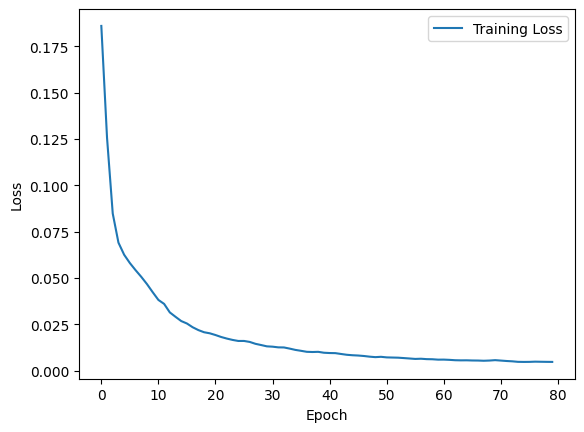

In [22]:
# Plot training history
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
def calculate_reconstruction_error(autoencoder, x_train, decoded_imgs):
    # Calculate the reconstruction error
    decoded_imgs = decoded_imgs.reshape(-1, 128, 128)
    reconstruction_error = tf.reduce_mean(tf.square(x_train - decoded_imgs), axis=(1, 2))
    return reconstruction_error.numpy()

In [24]:


# Prepare the input for the encoder manually
label_map = tf.reshape(park_pass_tensor, (-1, 1, 1, 8))
label_map = tf.tile(label_map, [1, 128, 128, 1])  # shape: (batch, 28, 28, 10)
x_input = tf.concat([x_train, label_map], axis=-1)  # shape: (batch, 28, 28, 11)

# Get latent space
latent_space = autoencoder.encoder(x_input).numpy()
print(latent_space.shape)  # Should be (num_samples, latent_dim)

decoded_imgs = autoencoder([x_train, park_pass_tensor])
decoded_imgs = decoded_imgs.numpy()  # Convert to NumPy for plotting

(295, 64)


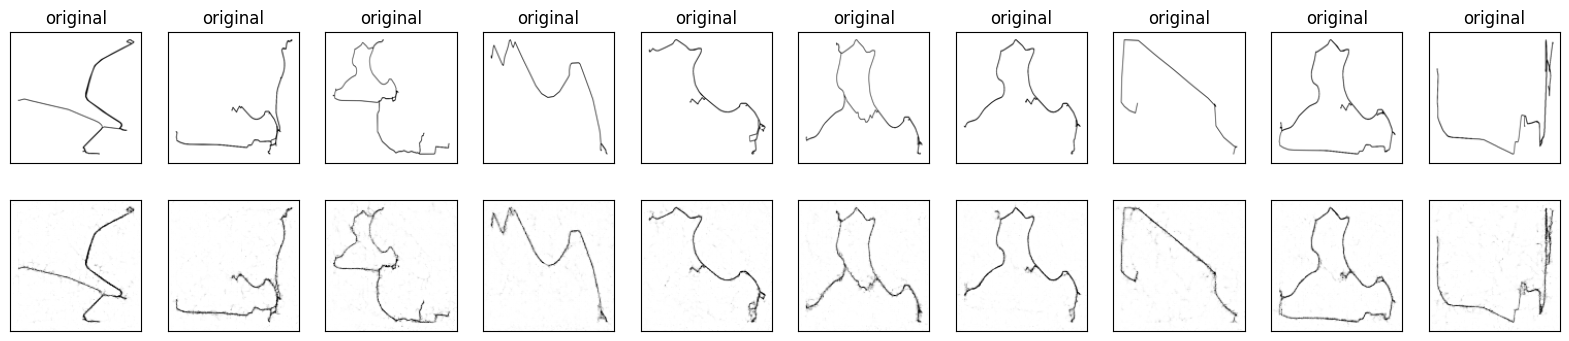

In [25]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # display original
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_train[i])
  plt.title("original")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs[i])
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.savefig('cnn_output.png')

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

In [27]:
PCA_post = PCA(n_components=21).fit_transform(latent_space)
PCA_post = normalize(PCA_post, norm="l2")
PCA_post = pd.DataFrame(PCA_post)

# Using silhouette_score to determine the number of clusters
from sklearn.metrics import silhouette_score
silhouette_scores = []
for i in range(2, 11):
     kmeans = KMeans(n_clusters=i, random_state=0)
     kmeans.fit(PCA_post)
     labels = kmeans.predict(PCA_post)
     silhouette_scores.append(silhouette_score(PCA_post, labels))

# find the optimal number of clusters
optimal_n_clusters = np.argmax(silhouette_scores) + 2
print(f"Optimal number of clusters for k-means clustering: {optimal_n_clusters}")

# Using k-means to cluster the data
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=0)
kmeans.fit(PCA_post)

# get the labels of the clusters
final_labels = labels = kmeans.labels_
# find the centers of the clusters
final_centers = kmeans.cluster_centers_
optimal_n_clusters_agglo = final_centers.shape[0]

cluster_labels = pd.DataFrame(final_labels)

/Users/yifuding/opt/anaconda3/envs/rio_tinto/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/yifuding/opt/anaconda3/envs/rio_tinto/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/yifuding/opt/anaconda3/envs/rio_tinto/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/yifuding/opt/anaconda3/envs/rio_tinto/lib/python3.8/site-packages/sklearn/clus

Optimal number of clusters for k-means clustering: 10


/Users/yifuding/opt/anaconda3/envs/rio_tinto/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/yifuding/opt/anaconda3/envs/rio_tinto/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/yifuding/opt/anaconda3/envs/rio_tinto/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [28]:
unique_labels = np.unique(cluster_labels)
print("Unique labels: ", unique_labels, cluster_labels.shape)


Unique labels:  [0 1 2 3 4 5 6 7 8 9] (295, 1)


In [29]:
#park_pass
park_pass_dataframe = pd.DataFrame()
hour_pass = pd.read_csv('hourly_passing_per_truck_1D_8SQ_CLUSTER_for_test_'+str(Vehicle_number)+'_R copy.csv')
for i in range(len(index)):
    park_pass = hour_pass[hour_pass[' TruckId'] == str(Vehicle_number)+'-'+str(i)]
    # sum the columns 2 to 26
    park_pass = park_pass.iloc[:, 2:27].sum(axis=1)
    park_pass_dataframe[i] = park_pass.values

# transfer all non-zero values to 1 
park_pass_dataframe[park_pass_dataframe > 0] = 1
print(park_pass_dataframe.head())

   0    1    2    3    4    5    6    7    8    9    ...  285  286  287  288  \
0    0    0    0    0    1    1    0    0    0    0  ...    0    0    1    0   
1    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    1    1    1    1    1    1    1    0    1    0  ...    1    0    1    0   
3    1    1    1    1    1    1    1    1    1    1  ...    1    1    1    1   
4    1    1    1    0    1    0    1    0    1    1  ...    0    1    1    0   

   289  290  291  292  293  294  
0    0    0    0    0    0    1  
1    0    0    0    1    0    0  
2    0    0    0    1    1    1  
3    1    1    1    1    1    1  
4    1    1    0    0    1    1  

[5 rows x 295 columns]


/var/folders/9p/t6ljp_1516q16t2lqgyjw0w80000gp/T/ipykernel_17567/1504477625.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  park_pass_dataframe[i] = park_pass.values
/var/folders/9p/t6ljp_1516q16t2lqgyjw0w80000gp/T/ipykernel_17567/1504477625.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  park_pass_dataframe[i] = park_pass.values
/var/folders/9p/t6ljp_1516q16t2lqgyjw0w80000gp/T/ipykernel_17567/1504477625.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [30]:
def get_row_indices_for_column(df, column_index):
    """
    Given a DataFrame `df` of 0/1 values and a column index,
    returns a list of all row indices where df.iloc[row, column_index] == 1.
    If there are no 1s in that column, returns 0.
    
    Parameters:
      df             – pd.DataFrame of binary values
      column_index   – integer index of the column to inspect
    
    Returns:
      list of int OR 0
    """
    # find all row indices where the column equals 1
    rows = (df.index[df.iloc[:, column_index] == 1]+1).tolist()
    
    return rows if rows else np.nan

# Example Usage
column_index = 100  # Specify the column you want to check
row_index = get_row_indices_for_column(park_pass_dataframe, column_index)
print(f"Row index of the first '1' in column {column_index}: {row_index}")

Row index of the first '1' in column 100: [4, 5, 8]


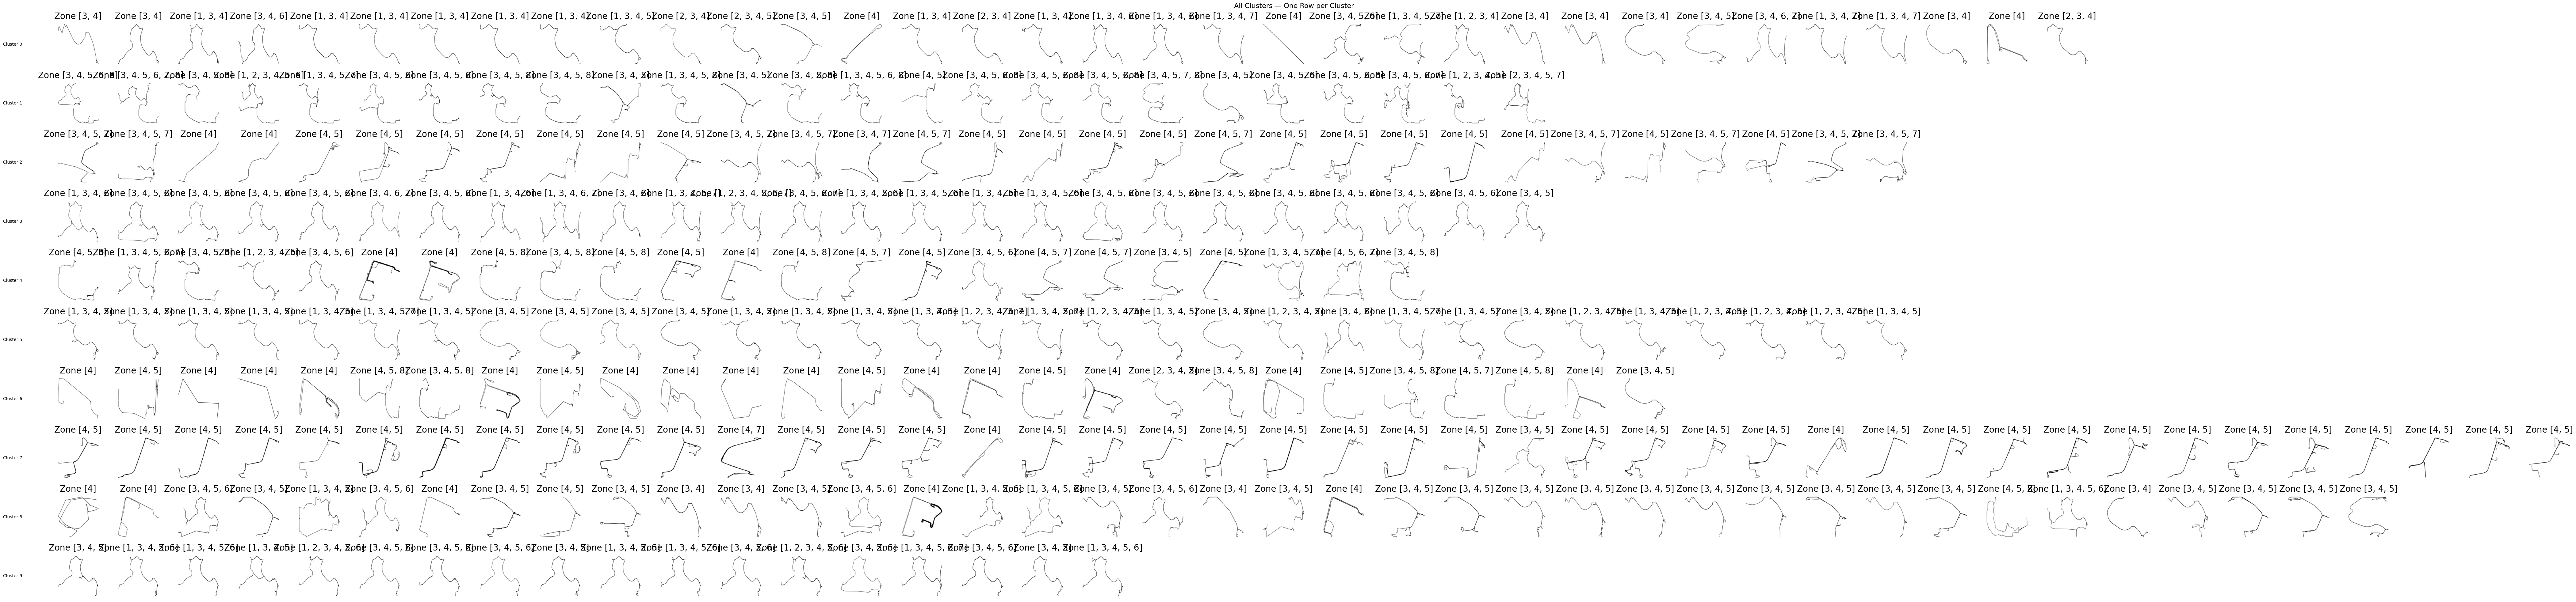

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


cluster_indices = [np.where(cluster_labels == label)[0] for label in unique_labels]
num_clusters = len(unique_labels)
max_imgs_in_row = max(len(indices) for indices in cluster_indices)


# Create overall figure
fig = plt.figure(figsize=(max_imgs_in_row * 2, num_clusters * 2))
gs = gridspec.GridSpec(num_clusters, max_imgs_in_row, figure=fig)

# Plot each cluster row
for row, (label, indices) in enumerate(zip(unique_labels, cluster_indices)):
    for col, idx in enumerate(indices):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(arr[idx, :, :], cmap='gray')
        ax.axis('off')
        parkzone = get_row_indices_for_column(park_pass_dataframe, idx)
        ax.set_title(f'Zone {parkzone}', fontsize=20)
    
    
    # Optional: Label cluster at start of row
    ax = fig.add_subplot(gs[row, 0])
    ax.text(-0.5, 0.5, f'Cluster {label}', fontsize=10, va='center', ha='right', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.suptitle('All Clusters — One Row per Cluster', fontsize=16)
plt.savefig('cluster_with_pass'+str(Vehicle_number)+'.png')